In [1]:
# --- Agregar mingw32-make al PATH de esta sesión de Python ---
import os

ruta_mingw = r"C:\Users\mgdbj\.cmdstan\RTools40\mingw64\bin"
os.environ["PATH"] = ruta_mingw + os.pathsep + os.environ["PATH"]

# Verificación: shutil.which busca en el PATH actual, igual que haría Windows
# al ejecutar el comando -- si esto imprime la ruta, ya está resuelto
import shutil
print(shutil.which("mingw32-make"))

C:\Users\mgdbj\.cmdstan\RTools40\mingw64\bin\mingw32-make.EXE


In [2]:
import cmdstanpy

ruta_cmdstan = r"C:\Users\mgdbj\miniconda3\envs\cmdstan_env\Library\bin\cmdstan"
cmdstanpy.set_cmdstan_path(ruta_cmdstan)

print("CmdStan path:", cmdstanpy.cmdstan_path())

C:\Users\mgdbj\xm-spot-price-predictor\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


CmdStan path: C:\Users\mgdbj\miniconda3\envs\cmdstan_env\Library\bin\cmdstan


In [3]:
from prophet import Prophet
import pandas as pd
import numpy as np

fechas = pd.date_range("2020-01-01", periods=200, freq="D")
juguete = pd.DataFrame({
    "ds": fechas,
    "y": 10 + 2 * np.sin(np.arange(200) * 2 * np.pi / 30) + np.random.normal(0, 0.5, 200)
})

modelo_prueba = Prophet()
modelo_prueba.fit(juguete)

futuro = modelo_prueba.make_future_dataframe(periods=10)
pronostico = modelo_prueba.predict(futuro)

print("Prophet instalado y funcionando correctamente.")
print(pronostico[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail())

Importing plotly failed. Interactive plots will not work.


14:55:53 - cmdstanpy - INFO - Chain [1] start processing


14:55:53 - cmdstanpy - INFO - Chain [1] done processing


Prophet instalado y funcionando correctamente.
            ds       yhat  yhat_lower  yhat_upper
205 2020-07-24   9.909628    8.012749   11.866997
206 2020-07-25  10.031359    8.127401   11.881606
207 2020-07-26  10.017943    7.986510   11.894801
208 2020-07-27   9.880924    7.903891   11.666767
209 2020-07-28   9.921627    7.953246   11.778076


In [4]:
# --- Celda de arranque: imports + ubicar la raíz del proyecto ---
import pandas as pd
from pathlib import Path

def encontrar_raiz_proyecto(marcador="requirements.txt"):
    actual = Path.cwd()
    for carpeta in [actual, *actual.parents]:
        if (carpeta / marcador).exists():
            return carpeta
    raise FileNotFoundError(f"No encontré '{marcador}' subiendo desde {actual}")

RAIZ = encontrar_raiz_proyecto()
print("Raíz del proyecto:", RAIZ)

Raíz del proyecto: C:\Users\mgdbj\xm-spot-price-predictor


In [5]:
# --- Celda 4 (corregida): Train = 2019-2025 completo, Test = 2026 real ---
ruta_train = RAIZ / "data" / "processed" / "dataset_maestro_2019_2025.csv"
ruta_test = RAIZ / "data" / "processed" / "dataset_maestro_2026.csv"

df_train_raw = pd.read_csv(ruta_train, parse_dates=["fecha_hora"])
df_test_raw = pd.read_csv(ruta_test, parse_dates=["fecha_hora"])

columnas_regresoras = ["aportes_hidricos", "volumen_embalses", "oni", "es_pandemia"]

train = df_train_raw.rename(columns={"fecha_hora": "ds", "precio_bolsa": "y"})[["ds", "y"] + columnas_regresoras]
test = df_test_raw.rename(columns={"fecha_hora": "ds", "precio_bolsa": "y"})[["ds", "y"] + columnas_regresoras]

print(f"Train: {train.shape[0]} filas ({train['ds'].min()} a {train['ds'].max()})")
print(f"Test:  {test.shape[0]} filas ({test['ds'].min()} a {test['ds'].max()})")

Train: 61368 filas (2019-01-01 00:00:00 a 2025-12-31 23:00:00)
Test:  5208 filas (2026-01-01 00:00:00 a 2026-08-05 23:00:00)


In [6]:
# --- Celda 6: Entrenar Prophet con TODO 2019-2025 ---
from prophet import Prophet

modelo = Prophet(daily_seasonality=True, weekly_seasonality=True, yearly_seasonality=True)
for columna in columnas_regresoras:
    modelo.add_regressor(columna)

modelo.fit(train)
print("Modelo entrenado con 2019-2025 completo.")

14:55:57 - cmdstanpy - INFO - Chain [1] start processing


14:57:46 - cmdstanpy - INFO - Chain [1] done processing


Modelo entrenado con 2019-2025 completo.


In [7]:
# --- Celda 7: Predecir sobre 2026 (backtesting real) ---
pronostico = modelo.predict(test[["ds"] + columnas_regresoras])
resultado = test[["ds", "y"]].merge(pronostico[["ds", "yhat"]], on="ds")

print("Predicciones negativas:", (resultado["yhat"] < 0).sum())
resultado.head()

Predicciones negativas: 27


,ds,y,yhat
0,2026-01-01 00:00:00,327.90985,283.553123
1,2026-01-01 01:00:00,307.90985,274.501045
2,2026-01-01 02:00:00,296.32185,268.893794
3,2026-01-01 03:00:00,296.32185,265.487801
4,2026-01-01 04:00:00,296.32185,266.160270


In [8]:
# --- Celda 8: Evaluar vs. persistencia ---
# El primer día de 2026 necesita el precio de 24h antes, que vive en train,
# no en test -- por eso se concatenan ambos antes de calcular el shift.
serie_completa = pd.concat([train[["ds", "y"]], test[["ds", "y"]]]).sort_values("ds").reset_index(drop=True)
resultado["persistencia"] = serie_completa.set_index("ds")["y"].shift(24).reindex(resultado["ds"]).values

def calcular_metricas(y_real, y_pred, nombre):
    error = y_real - y_pred
    mae = error.abs().mean()
    rmse = (error ** 2).mean() ** 0.5
    mape = (error.abs() / y_real).mean() * 100
    print(f"{nombre:15s} MAE: {mae:8.2f}  RMSE: {rmse:8.2f}  MAPE: {mape:6.2f}%")

calcular_metricas(resultado["y"], resultado["yhat"], "Prophet")
calcular_metricas(resultado["y"], resultado["persistencia"], "Persistencia")

Prophet         MAE:   195.07  RMSE:   260.93  MAPE:  65.12%
Persistencia    MAE:    56.31  RMSE:   112.22  MAPE:  15.75%


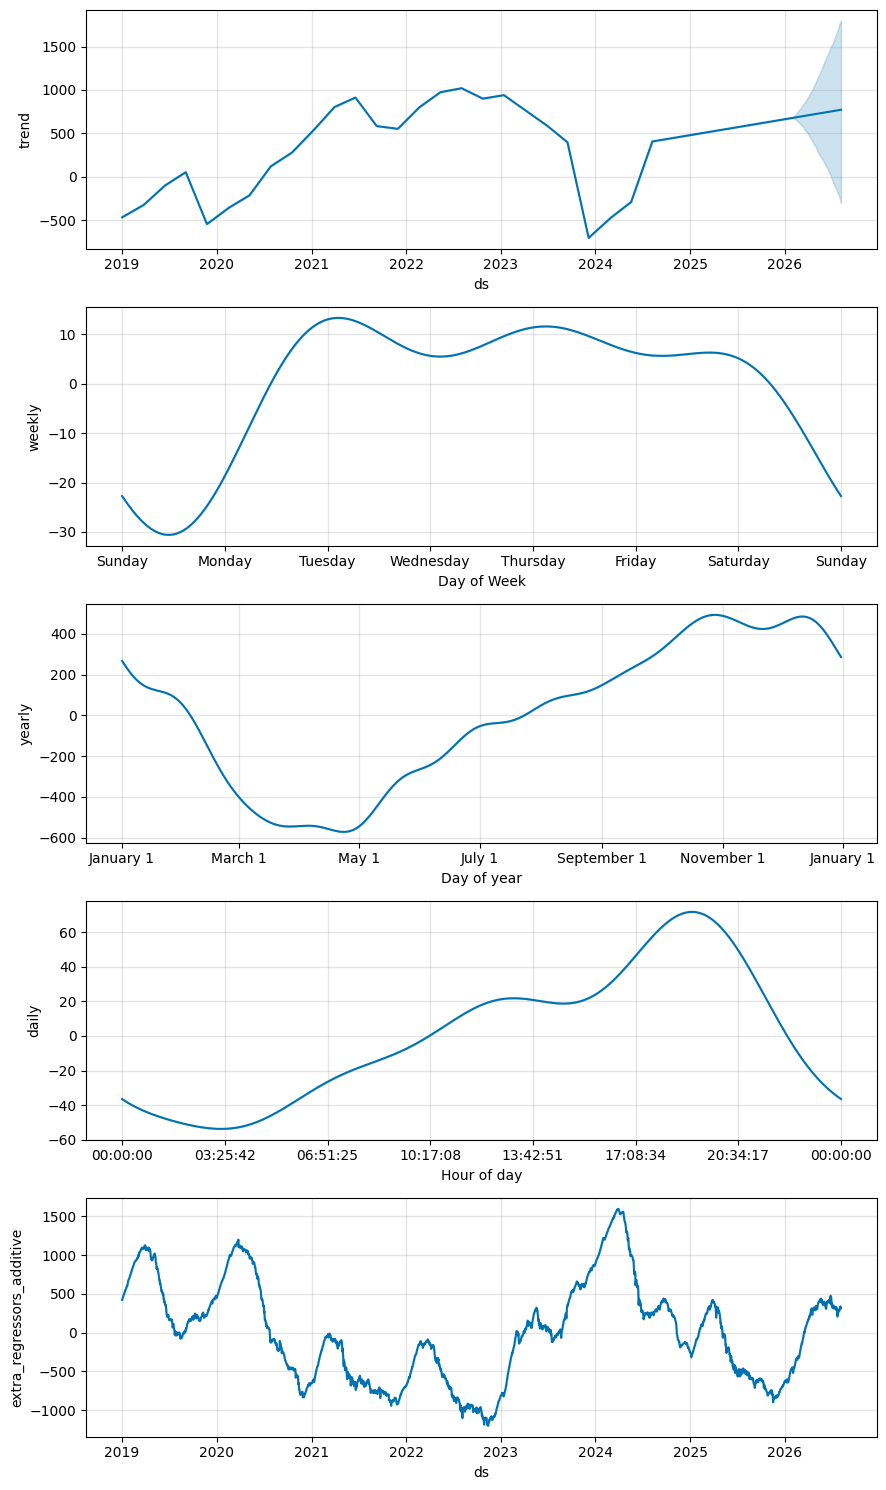

In [9]:
# --- Ver el desglose de componentes del modelo actual ---
pronostico_completo = modelo.predict(pd.concat([
    train[["ds"] + columnas_regresoras],
    test[["ds"] + columnas_regresoras]
], ignore_index=True))

fig = modelo.plot_components(pronostico_completo)

In [10]:
# --- Reentrenar con log(precio) + precio de hace 24h como regresor ---
import numpy as np

# Precio de hace 24h: se calcula sobre la serie completa (train+test) para que
# el 1 de enero de 2026 sí tenga acceso al 31 de diciembre de 2025, aunque ese
# dato viva en train.
serie_completa = pd.concat([train[["ds", "y"]], test[["ds", "y"]]]).sort_values("ds").reset_index(drop=True)
serie_completa["precio_lag24"] = serie_completa["y"].shift(24)

train2 = train.merge(serie_completa[["ds", "precio_lag24"]], on="ds").dropna(subset=["precio_lag24"])
test2 = test.merge(serie_completa[["ds", "precio_lag24"]], on="ds")

train2["y"] = np.log(train2["y"])  # log-transform del target

columnas_regresoras2 = columnas_regresoras + ["precio_lag24"]

modelo2 = Prophet(daily_seasonality=True, weekly_seasonality=True, yearly_seasonality=True)
for columna in columnas_regresoras2:
    modelo2.add_regressor(columna)
modelo2.fit(train2)

pronostico2 = modelo2.predict(test2[["ds"] + columnas_regresoras2])
resultado2 = test2[["ds", "y"]].merge(pronostico2[["ds", "yhat"]], on="ds")
resultado2["yhat"] = np.exp(resultado2["yhat"])  # deshacer el log

print("Predicciones negativas:", (resultado2["yhat"] < 0).sum())  # debería ser 0
calcular_metricas(resultado2["y"], resultado2["yhat"], "Prophet v2")
calcular_metricas(resultado2["y"], resultado["persistencia"].values, "Persistencia")

14:57:59 - cmdstanpy - INFO - Chain [1] start processing


14:59:08 - cmdstanpy - INFO - Chain [1] done processing


Predicciones negativas: 0
Prophet v2      MAE:   229.07  RMSE:   326.62  MAPE:  46.36%
Persistencia    MAE:    56.31  RMSE:   112.22  MAPE:  15.75%


In [11]:
# --- Diagnóstico: ¿el error crece con el nivel de precio/ONI? ---
resultado2 = resultado2.merge(test2[["ds", "oni"]], on="ds")
resultado2["error_abs"] = (resultado2["y"] - resultado2["yhat"]).abs()

mediana_oni = resultado2["oni"].median()
alto_oni = resultado2[resultado2["oni"] >= mediana_oni]
bajo_oni = resultado2[resultado2["oni"] < mediana_oni]

print(f"Error medio con ONI alto (>= {mediana_oni:.2f}): {alto_oni['error_abs'].mean():.2f}  (n={len(alto_oni)})")
print(f"Error medio con ONI bajo (< {mediana_oni:.2f}):  {bajo_oni['error_abs'].mean():.2f}  (n={len(bajo_oni)})")
print("\nCorrelación entre precio real y error absoluto:", resultado2["y"].corr(resultado2["error_abs"]))

Error medio con ONI alto (>= 0.35): 390.43  (n=2604)
Error medio con ONI bajo (< 0.35):  67.70  (n=2604)

Correlación entre precio real y error absoluto: 0.9739949335941527


In [12]:
# --- Reentrenar: log(y) Y log(precio_lag24), ambos en la misma escala ---
train3 = train2.copy()
test3 = test2.copy()

train3["precio_lag24"] = np.log(train3["precio_lag24"])
test3["precio_lag24"] = np.log(test3["precio_lag24"])

modelo3 = Prophet(daily_seasonality=True, weekly_seasonality=True, yearly_seasonality=True)
for columna in columnas_regresoras2:
    modelo3.add_regressor(columna)
modelo3.fit(train3)

pronostico3 = modelo3.predict(test3[["ds"] + columnas_regresoras2])
resultado3 = test3[["ds", "y"]].merge(pronostico3[["ds", "yhat"]], on="ds")
resultado3["yhat"] = np.exp(resultado3["yhat"])

print("Predicciones negativas:", (resultado3["yhat"] < 0).sum())
calcular_metricas(resultado3["y"], resultado3["yhat"], "Prophet v3")

14:59:13 - cmdstanpy - INFO - Chain [1] start processing


14:59:55 - cmdstanpy - INFO - Chain [1] done processing


Predicciones negativas: 0
Prophet v3      MAE:    96.80  RMSE:   150.74  MAPE:  20.33%


In [13]:
# --- Grid search sobre hiperparámetros, validando con 2025 ---
# IMPORTANTE: 2026 NO se toca aquí. Se entrena con 2019-2024, se valida con
# 2025, y solo al final la mejor configuración se evalúa contra 2026.
import itertools
import time

train_gs = train3[train3["ds"] < "2025-01-01"].copy()
valid_gs = train3[train3["ds"] >= "2025-01-01"].copy()

print(f"Train GS: {len(train_gs)} filas | Valid GS: {len(valid_gs)} filas")

# La rejilla: cada combinación es un entrenamiento completo (~90s), así que
# 12 combos son ~18 minutos. Empezamos chico a propósito -- si vale la pena,
# se refina después alrededor del mejor valor encontrado.
rejilla = {
    "changepoint_prior_scale": [0.01, 0.05, 0.5],   # 0.05 es el default
    "seasonality_prior_scale": [1.0, 10.0],          # 10.0 es el default
    "seasonality_mode": ["additive", "multiplicative"],
}

combinaciones = [dict(zip(rejilla.keys(), valores))
                 for valores in itertools.product(*rejilla.values())]
print(f"Total de combinaciones: {len(combinaciones)}\n")

resultados_gs = []
for i, params in enumerate(combinaciones, 1):
    inicio = time.time()
    m = Prophet(daily_seasonality=True, weekly_seasonality=True,
                yearly_seasonality=True, **params)
    for columna in columnas_regresoras2:
        m.add_regressor(columna)
    m.fit(train_gs)

    pred = m.predict(valid_gs[["ds"] + columnas_regresoras2])
    y_real = np.exp(valid_gs["y"].values)      # deshacer el log para comparar en COP/kWh
    y_pred = np.exp(pred["yhat"].values)

    mae = np.abs(y_real - y_pred).mean()
    mape = (np.abs(y_real - y_pred) / y_real).mean() * 100

    resultados_gs.append({**params, "mae": mae, "mape": mape})
    print(f"[{i}/{len(combinaciones)}] {params} -> MAE {mae:.2f} | MAPE {mape:.2f}% ({time.time()-inicio:.0f}s)")

df_gs = pd.DataFrame(resultados_gs).sort_values("mae").reset_index(drop=True)
df_gs

Train GS: 52584 filas | Valid GS: 8760 filas
Total de combinaciones: 12



14:59:59 - cmdstanpy - INFO - Chain [1] start processing


15:00:25 - cmdstanpy - INFO - Chain [1] done processing


[1/12] {'changepoint_prior_scale': 0.01, 'seasonality_prior_scale': 1.0, 'seasonality_mode': 'additive'} -> MAE 48.68 | MAPE 18.76% (31s)


15:00:30 - cmdstanpy - INFO - Chain [1] start processing


...

[11/12] {'changepoint_prior_scale': 0.5, 'seasonality_prior_scale': 10.0, 'seasonality_mode': 'additive'} -> MAE 79.61 | MAPE 32.01% (57s)


15:08:25 - cmdstanpy - INFO - Chain [1] start processing


15:09:13 - cmdstanpy - INFO - Chain [1] done processing


[12/12] {'changepoint_prior_scale': 0.5, 'seasonality_prior_scale': 10.0, 'seasonality_mode': 'multiplicative'} -> MAE 73.27 | MAPE 28.29% (53s)


,changepoint_prior_scale,seasonality_prior_scale,seasonality_mode,mae,mape
0,0.01,1.0,multiplicative,48.253293,18.792786
1,0.01,10.0,additive,48.261513,18.705587
2,0.01,10.0,multiplicative,48.563788,18.857828
3,0.01,1.0,additive,48.683263,18.759346
4,0.05,10.0,multiplicative,62.128427,23.558626
5,0.05,1.0,multiplicative,64.332908,24.451862
6,0.05,10.0,additive,66.251766,25.688620
7,0.05,1.0,additive,66.292063,25.724487
8,0.50,1.0,multiplicative,71.537681,27.554662
9,0.50,10.0,multiplicative,73.267257,28.293247


In [14]:
# --- Persistencia en el MISMO tramo de validación (2025), para comparación justa ---
persistencia_2025 = serie_completa[
    (serie_completa["ds"] >= "2025-01-01") & (serie_completa["ds"] < "2026-01-01")
].dropna(subset=["precio_lag24"])

calcular_metricas(persistencia_2025["y"], persistencia_2025["precio_lag24"], "Persistencia (2025)")

Persistencia (2025) MAE:    45.95  RMSE:   103.39  MAPE:  18.05%


In [15]:
# --- Grid search refinado: acercarse más a cps=0.01 ---
rejilla_fina = [0.001, 0.005, 0.01, 0.02]

resultados_gs2 = []
for i, cps in enumerate(rejilla_fina, 1):
    inicio = time.time()
    m = Prophet(daily_seasonality=True, weekly_seasonality=True, yearly_seasonality=True,
                changepoint_prior_scale=cps, seasonality_prior_scale=10.0, seasonality_mode="additive")
    for columna in columnas_regresoras2:
        m.add_regressor(columna)
    m.fit(train_gs)

    pred = m.predict(valid_gs[["ds"] + columnas_regresoras2])
    y_real = np.exp(valid_gs["y"].values)
    y_pred = np.exp(pred["yhat"].values)

    mae = np.abs(y_real - y_pred).mean()
    mape = (np.abs(y_real - y_pred) / y_real).mean() * 100

    resultados_gs2.append({"changepoint_prior_scale": cps, "mae": mae, "mape": mape})
    print(f"[{i}/{len(rejilla_fina)}] cps={cps} -> MAE {mae:.2f} | MAPE {mape:.2f}% ({time.time()-inicio:.0f}s)")

df_gs2 = pd.DataFrame(resultados_gs2).sort_values("mae").reset_index(drop=True)
df_gs2

15:09:18 - cmdstanpy - INFO - Chain [1] start processing


15:09:26 - cmdstanpy - INFO - Chain [1] done processing


[1/4] cps=0.001 -> MAE 48.60 | MAPE 21.61% (13s)


15:09:31 - cmdstanpy - INFO - Chain [1] start processing


15:09:52 - cmdstanpy - INFO - Chain [1] done processing


...

[3/4] cps=0.01 -> MAE 48.26 | MAPE 18.71% (32s)


15:10:29 - cmdstanpy - INFO - Chain [1] start processing


15:11:03 - cmdstanpy - INFO - Chain [1] done processing


[4/4] cps=0.02 -> MAE 56.91 | MAPE 21.75% (39s)


,changepoint_prior_scale,mae,mape
0,0.005,45.905207,18.003399
1,0.010,48.261513,18.705587
2,0.001,48.598661,21.605603
3,0.020,56.908801,21.747556


In [16]:
# --- Grid search refinado: acercarse más a cps=0.01, con la persistencia como referencia ---
persistencia_mae = 45.95  # ya calculado, misma ventana de validación (2025)

rejilla_fina = [0.001, 0.005, 0.01, 0.02]

resultados_gs2 = []
for i, cps in enumerate(rejilla_fina, 1):
    inicio = time.time()
    m = Prophet(daily_seasonality=True, weekly_seasonality=True, yearly_seasonality=True,
                changepoint_prior_scale=cps, seasonality_prior_scale=10.0, seasonality_mode="additive")
    for columna in columnas_regresoras2:
        m.add_regressor(columna)
    m.fit(train_gs)

    pred = m.predict(valid_gs[["ds"] + columnas_regresoras2])
    y_real = np.exp(valid_gs["y"].values)
    y_pred = np.exp(pred["yhat"].values)

    mae = np.abs(y_real - y_pred).mean()
    mape = (np.abs(y_real - y_pred) / y_real).mean() * 100
    diferencia = mae - persistencia_mae

    resultados_gs2.append({"changepoint_prior_scale": cps, "mae": mae, "mape": mape})
    marca = "✓ le gana a persistencia" if diferencia < 0 else f"pierde por {diferencia:.2f}"
    print(f"[{i}/{len(rejilla_fina)}] cps={cps} -> MAE {mae:.2f} | MAPE {mape:.2f}% | {marca} ({time.time()-inicio:.0f}s)")

df_gs2 = pd.DataFrame(resultados_gs2).sort_values("mae").reset_index(drop=True)
df_gs2

15:11:08 - cmdstanpy - INFO - Chain [1] start processing


15:11:16 - cmdstanpy - INFO - Chain [1] done processing


[1/4] cps=0.001 -> MAE 48.60 | MAPE 21.61% | pierde por 2.65 (12s)


15:11:20 - cmdstanpy - INFO - Chain [1] start processing


15:11:42 - cmdstanpy - INFO - Chain [1] done processing


...

[3/4] cps=0.01 -> MAE 48.26 | MAPE 18.71% | pierde por 2.31 (31s)


15:12:17 - cmdstanpy - INFO - Chain [1] start processing


15:12:53 - cmdstanpy - INFO - Chain [1] done processing


[4/4] cps=0.02 -> MAE 56.91 | MAPE 21.75% | pierde por 10.96 (41s)


,changepoint_prior_scale,mae,mape
0,0.005,45.905207,18.003399
1,0.010,48.261513,18.705587
2,0.001,48.598661,21.605603
3,0.020,56.908801,21.747556


In [17]:
# --- Celda A: Reanudar sesión ---
import pandas as pd
import numpy as np
from pathlib import Path
from prophet import Prophet

def encontrar_raiz_proyecto(marcador="requirements.txt"):
    actual = Path.cwd()
    for carpeta in [actual, *actual.parents]:
        if (carpeta / marcador).exists():
            return carpeta
    raise FileNotFoundError(f"No encontré '{marcador}' subiendo desde {actual}")

RAIZ = encontrar_raiz_proyecto()
print("Raíz del proyecto:", RAIZ)

def calcular_metricas(y_real, y_pred, nombre):
    y_real, y_pred = np.asarray(y_real), np.asarray(y_pred)
    error = y_real - y_pred
    mae = np.abs(error).mean()
    rmse = np.sqrt((error ** 2).mean())
    mape = (np.abs(error) / y_real).mean() * 100
    print(f"{nombre:25s} MAE: {mae:8.2f}  RMSE: {rmse:8.2f}  MAPE: {mape:6.2f}%")
    return mae, rmse, mape

Raíz del proyecto: C:\Users\mgdbj\xm-spot-price-predictor


In [18]:
# --- Celda B: Cargar 2019-2025 (train) y 2026 (test), con la transformación ganadora ---
columnas_regresoras = ["aportes_hidricos", "volumen_embalses", "oni", "es_pandemia"]
columnas_regresoras2 = columnas_regresoras + ["precio_lag24"]

df_train_raw = pd.read_csv(RAIZ / "data" / "processed" / "dataset_maestro_2019_2025.csv", parse_dates=["fecha_hora"])
df_test_raw = pd.read_csv(RAIZ / "data" / "processed" / "dataset_maestro_2026.csv", parse_dates=["fecha_hora"])

train = df_train_raw.rename(columns={"fecha_hora": "ds", "precio_bolsa": "y"})[["ds", "y"] + columnas_regresoras]
test = df_test_raw.rename(columns={"fecha_hora": "ds", "precio_bolsa": "y"})[["ds", "y"] + columnas_regresoras]

# precio_lag24 sobre la serie completa, para que el 1 ene 2026 vea el 31 dic 2025
serie_completa = pd.concat([train[["ds", "y"]], test[["ds", "y"]]]).sort_values("ds").reset_index(drop=True)
serie_completa["precio_lag24"] = serie_completa["y"].shift(24)

train = train.merge(serie_completa[["ds", "precio_lag24"]], on="ds").dropna(subset=["precio_lag24"])
test = test.merge(serie_completa[["ds", "precio_lag24"]], on="ds")

# La transformación de v3: log en 'y' Y en 'precio_lag24', misma escala
train_final, test_final = train.copy(), test.copy()
train_final["y"] = np.log(train_final["y"])
train_final["precio_lag24"] = np.log(train_final["precio_lag24"])
test_final["precio_lag24"] = np.log(test_final["precio_lag24"])

print(f"Train: {len(train_final)} filas | Test: {len(test_final)} filas")

Train: 61344 filas | Test: 5208 filas


In [19]:
# --- Celda C: Entrenar el modelo final, cps=0.005, sobre 2019-2025 completo ---
modelo_final = Prophet(
    daily_seasonality=True, weekly_seasonality=True, yearly_seasonality=True,
    changepoint_prior_scale=0.005,
)
for columna in columnas_regresoras2:
    modelo_final.add_regressor(columna)

modelo_final.fit(train_final)
print("Modelo final entrenado.")

15:13:02 - cmdstanpy - INFO - Chain [1] start processing


15:13:46 - cmdstanpy - INFO - Chain [1] done processing


Modelo final entrenado.


In [20]:
# --- Celda D: EL vistazo honesto -- evaluación única contra 2026 ---
pronostico_final = modelo_final.predict(test_final[["ds"] + columnas_regresoras2])
resultado_final = test_final[["ds", "y"]].merge(pronostico_final[["ds", "yhat"]], on="ds")
resultado_final["yhat"] = np.exp(resultado_final["yhat"])

print("Predicciones negativas:", (resultado_final["yhat"] < 0).sum())

persistencia_2026 = serie_completa[serie_completa["ds"] >= "2026-01-01"].dropna(subset=["precio_lag24"])

calcular_metricas(resultado_final["y"].values, resultado_final["yhat"].values, "Prophet final (cps=0.005)")
calcular_metricas(persistencia_2026["y"].values, persistencia_2026["precio_lag24"].values, "Persistencia 2026")

Predicciones negativas: 0
Prophet final (cps=0.005) MAE:    91.66  RMSE:   144.00  MAPE:  19.57%
Persistencia 2026         MAE:    56.31  RMSE:   112.22  MAPE:  15.75%


(np.float64(56.308405618279565),
 np.float64(112.22281657799465),
 np.float64(15.75262665117942))

In [21]:
# --- Diagnóstico: ¿el error en 2026 se concentra donde el Niño ya se siente más? ---
resultado_final = resultado_final.merge(test[["ds", "oni"]], on="ds")
resultado_final["error_abs"] = (resultado_final["y"] - resultado_final["yhat"]).abs()

mediana_oni_2026 = resultado_final["oni"].median()
alto = resultado_final[resultado_final["oni"] >= mediana_oni_2026]
bajo = resultado_final[resultado_final["oni"] < mediana_oni_2026]

print(f"Error medio con ONI alto (>= {mediana_oni_2026:.2f}): {alto['error_abs'].mean():.2f}  (n={len(alto)})")
print(f"Error medio con ONI bajo (< {mediana_oni_2026:.2f}):  {bajo['error_abs'].mean():.2f}  (n={len(bajo)})")

Error medio con ONI alto (>= 0.35): 150.48  (n=2604)
Error medio con ONI bajo (< 0.35):  32.84  (n=2604)


In [22]:
# --- Construir ONI rezagado 3, 6 y 9 meses ---
ruta_oni = RAIZ / "data" / "external" / "oni_index.csv"
oni_ancho = pd.read_csv(ruta_oni)
columnas_temporada = ["DJF","JFM","FMA","MAM","AMJ","MJJ","JJA","JAS","ASO","SON","OND","NDJ"]
mes_central = {temp: i + 1 for i, temp in enumerate(columnas_temporada)}
oni_largo = oni_ancho.melt(id_vars="anio", value_vars=columnas_temporada, var_name="temporada", value_name="oni")
oni_largo["mes"] = oni_largo["temporada"].map(mes_central)
oni_largo = oni_largo[["anio", "mes", "oni"]].sort_values(["anio", "mes"]).reset_index(drop=True)

for lag in [3, 6, 9]:
    oni_largo[f"oni_lag{lag}m"] = oni_largo["oni"].shift(lag)

oni_largo.tail(12)

,anio,mes,oni,oni_lag3m,oni_lag6m,oni_lag9m
84,2026,1,-0.4,-0.6,-0.1,0.0
85,2026,2,-0.2,-0.6,-0.3,0.0
86,2026,3,0.1,-0.6,-0.4,0.0
87,2026,4,0.5,-0.4,-0.6,-0.1
88,2026,5,0.9,-0.2,-0.6,-0.3
89,2026,6,1.4,0.1,-0.6,-0.4
90,2026,7,1.4,0.5,-0.4,-0.6
91,2026,8,1.4,0.9,-0.2,-0.6
92,2026,9,1.4,1.4,0.1,-0.6
93,2026,10,1.4,1.4,0.5,-0.4


In [23]:
# --- Unir los rezagos a train/valid (2019-2024 / 2025), mismo split del grid search ---
train_gs = train_final[train_final["ds"] < "2025-01-01"].copy()
valid_gs = train_final[train_final["ds"] >= "2025-01-01"].copy()

for df in (train_gs, valid_gs):
    df["anio"] = df["ds"].dt.year
    df["mes"] = df["ds"].dt.month

cols_lag = ["oni_lag3m", "oni_lag6m", "oni_lag9m"]
train_gs = train_gs.merge(oni_largo[["anio", "mes"] + cols_lag], on=["anio", "mes"], how="left")
valid_gs = valid_gs.merge(oni_largo[["anio", "mes"] + cols_lag], on=["anio", "mes"], how="left")

# Los primeros meses de 2019 se quedan sin rezago de 9 meses (no hay 2018) --
# se caen del entrenamiento, un costo chico frente a 6 años de datos.
train_gs = train_gs.dropna(subset=cols_lag)

print("Nulos en rezagos (valid):", valid_gs[cols_lag].isna().sum().sum())
print(f"Train: {len(train_gs)} filas | Valid: {len(valid_gs)} filas")

Nulos en rezagos (valid): 0
Train: 46056 filas | Valid: 8760 filas


In [24]:
# --- Entrenar con ONI rezagado agregado, mismo cps=0.005 ya encontrado ---
columnas_regresoras_lag = columnas_regresoras2 + cols_lag

modelo_lag = Prophet(daily_seasonality=True, weekly_seasonality=True, yearly_seasonality=True,
                      changepoint_prior_scale=0.005)
for columna in columnas_regresoras_lag:
    modelo_lag.add_regressor(columna)
modelo_lag.fit(train_gs)

pred_lag = modelo_lag.predict(valid_gs[["ds"] + columnas_regresoras_lag])
y_real = np.exp(valid_gs["y"].values)
y_pred = np.exp(pred_lag["yhat"].values)

calcular_metricas(y_real, y_pred, "Prophet + ONI rezagado (valid 2025)")
print("Referencia -- sin rezagos: MAE 45.64 | Persistencia: MAE 45.95")

15:13:53 - cmdstanpy - INFO - Chain [1] start processing


15:14:23 - cmdstanpy - INFO - Chain [1] done processing


Prophet + ONI rezagado (valid 2025) MAE:    50.53  RMSE:    96.89  MAPE:  18.75%
Referencia -- sin rezagos: MAE 45.64 | Persistencia: MAE 45.95


SECCION FINAL LUEGO DE VERIFICAR ERRORES 

In [25]:
# --- Celda A: Recargar y corregir la misma fuga que se encontró en XGBoost ---
df_maestro_train = pd.read_csv(RAIZ / "data" / "processed" / "dataset_maestro_2019_2025.csv", parse_dates=["fecha_hora"])
df_maestro_test = pd.read_csv(RAIZ / "data" / "processed" / "dataset_maestro_2026.csv", parse_dates=["fecha_hora"])

serie_completa_p = pd.concat([df_maestro_train, df_maestro_test]).sort_values("fecha_hora").reset_index(drop=True)

H = 24
serie_completa_p["aportes_hidricos"] = serie_completa_p["aportes_hidricos"].shift(H)
serie_completa_p["volumen_embalses"] = serie_completa_p["volumen_embalses"].shift(H)
serie_completa_p["precio_lag24h"] = serie_completa_p["precio_bolsa"].shift(H)  # esto ES la persistencia

fechas_train = set(df_maestro_train["fecha_hora"])
fechas_test = set(df_maestro_test["fecha_hora"])

df_train_p = serie_completa_p[serie_completa_p["fecha_hora"].isin(fechas_train)].reset_index(drop=True)
df_test_p = serie_completa_p[serie_completa_p["fecha_hora"].isin(fechas_test)].reset_index(drop=True)

persistencia_2026_p = df_test_p["precio_lag24h"].values.copy()  # guardada en escala real, antes de logaritmar nada

print(f"Train: {df_train_p.shape} | Test: {df_test_p.shape}")

Train: (61368, 9) | Test: (5208, 9)


In [ ]:
# --- Celda B: Preparar para Prophet (log-transform, formato ds/y) ---
# Festivos agregados 2026-09-10: confirmado con significancia estadistica en N-BEATSx (p=0.0064).
# Prophet lee dataset_maestro directo (no dataset_features), asi que se construyen aqui mismo.
import holidays
_festivos_co = set(holidays.CO(years=range(2018, 2028)).keys())
_fecha_norm = serie_completa_p["fecha_hora"].dt.normalize()
def _festivo_desplazado(dias):
    return (_fecha_norm - pd.Timedelta(days=dias)).dt.date.map(lambda d: d in _festivos_co).astype(int)
serie_completa_p["es_festivo"] = _festivo_desplazado(0)
serie_completa_p["festivo_lag24h"] = _festivo_desplazado(1)
serie_completa_p["festivo_lag48h"] = _festivo_desplazado(2)
serie_completa_p["festivo_lag72h"] = _festivo_desplazado(3)
serie_completa_p["festivo_lag168h"] = _festivo_desplazado(7)
serie_completa_p["mismatch_festivo_24h"] = (serie_completa_p["es_festivo"] != serie_completa_p["festivo_lag24h"]).astype(int)
serie_completa_p["mismatch_festivo_168h"] = (serie_completa_p["es_festivo"] != serie_completa_p["festivo_lag168h"]).astype(int)

columnas_festivo = ["es_festivo", "festivo_lag24h", "festivo_lag48h", "festivo_lag72h",
                     "festivo_lag168h", "mismatch_festivo_24h", "mismatch_festivo_168h"]
columnas_regresoras2 = ["aportes_hidricos", "volumen_embalses", "oni", "es_pandemia", "precio_lag24h"] + columnas_festivo

df_train_p = df_train_p.merge(serie_completa_p[["fecha_hora"] + columnas_festivo], on="fecha_hora", how="left")
df_test_p = df_test_p.merge(serie_completa_p[["fecha_hora"] + columnas_festivo], on="fecha_hora", how="left")

train_final = df_train_p.rename(columns={"fecha_hora": "ds", "precio_bolsa": "y"})[["ds", "y"] + columnas_regresoras2].dropna()
test_final = df_test_p.rename(columns={"fecha_hora": "ds", "precio_bolsa": "y"})[["ds", "y"] + columnas_regresoras2]

train_final["y"] = np.log(train_final["y"])
train_final["precio_lag24h"] = np.log(train_final["precio_lag24h"])
test_final["precio_lag24h"] = np.log(test_final["precio_lag24h"])

print(f"Train listo: {len(train_final)} | Test listo: {len(test_final)}")

In [27]:
# --- Celda C: Reentrenar con la configuración YA elegida (cps=0.005) -- no se re-tunea ---
from prophet import Prophet

modelo_final_v2 = Prophet(
    daily_seasonality=True, weekly_seasonality=True, yearly_seasonality=True,
    changepoint_prior_scale=0.005,
)
for columna in columnas_regresoras2:
    modelo_final_v2.add_regressor(columna)

modelo_final_v2.fit(train_final)
print("Modelo reentrenado con datos corregidos.")

15:14:34 - cmdstanpy - INFO - Chain [1] start processing


15:15:20 - cmdstanpy - INFO - Chain [1] done processing


Modelo reentrenado con datos corregidos.


In [28]:
# --- Celda D (CORREGIDA): Evaluación final, limpia ---
pronostico_v2 = modelo_final_v2.predict(test_final[["ds"] + columnas_regresoras2])
resultado_v2 = test_final[["ds", "y"]].merge(pronostico_v2[["ds", "yhat"]], on="ds")

# "y" en test_final nunca se logaritmó -- ya está en escala real, se usa tal cual.
# Solo "yhat" viene en escala log (así entrenó el modelo) y necesita exp().
y_real_v2 = resultado_v2["y"].values
y_pred_v2 = np.exp(resultado_v2["yhat"]).values

print("Predicciones negativas:", (y_pred_v2 < 0).sum())
calcular_metricas(y_real_v2, y_pred_v2, "Prophet final (datos corregidos)")
calcular_metricas(y_real_v2, persistencia_2026_p, "Persistencia")
print("\nReferencia -- Prophet con la fuga: MAE 89.09 | RMSE 140.52 | MAPE 19.29%")

Predicciones negativas: 0
Prophet final (datos corregidos) MAE:    95.84  RMSE:   150.22  MAPE:  19.93%
Persistencia              MAE:    56.31  RMSE:   112.22  MAPE:  15.75%

Referencia -- Prophet con la fuga: MAE 89.09 | RMSE 140.52 | MAPE 19.29%


In [29]:
# --- Celda E (CORREGIDA): Diagnóstico de régimen ---
resultado_v2["oni"] = test_final["oni"].values
resultado_v2["error_abs"] = np.abs(y_real_v2 - y_pred_v2)

mediana_oni_p = resultado_v2["oni"].median()
alto_p = resultado_v2[resultado_v2["oni"] >= mediana_oni_p]
bajo_p = resultado_v2[resultado_v2["oni"] < mediana_oni_p]

print(f"Prophet corregido -- ONI alto: {alto_p['error_abs'].mean():.2f}  |  ONI bajo: {bajo_p['error_abs'].mean():.2f}  |  razón {alto_p['error_abs'].mean()/bajo_p['error_abs'].mean():.2f}x")
print("Referencia -- Prophet con la fuga: 133.71 vs 26.13 (razón 5.1x)")

Prophet corregido -- ONI alto: 159.34  |  ONI bajo: 32.34  |  razón 4.93x
Referencia -- Prophet con la fuga: 133.71 vs 26.13 (razón 5.1x)
